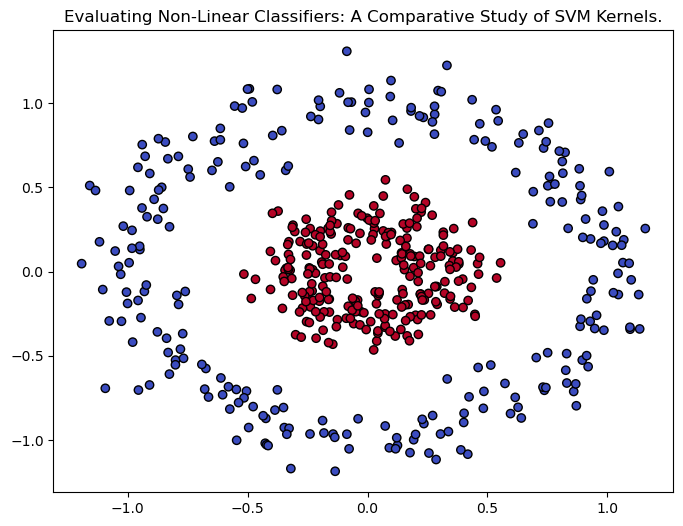

In [7]:
# Individual Assignment: Machine Learning Tutorial
#Author: Mobasshir Mahmud  
#Student ID: 24128563  
#University: University of Hertfordshire  
#GitHub Repository: https://github.com/mobasshiremon-uk/Individual-Assignment-Machine-Learning-Tutorial.git

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

# Re-creating your dataset
# n_samples = total dots
# factor = distance between inner and outer circle
# noise = how "messy" the dots are
X, y = make_circles(n_samples=500, factor=0.3, noise=0.1, random_state=42)

# Quick visualization to confirm it's back
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title("Evaluating Non-Linear Classifiers: A Comparative Study of SVM Kernels.")
plt.show()

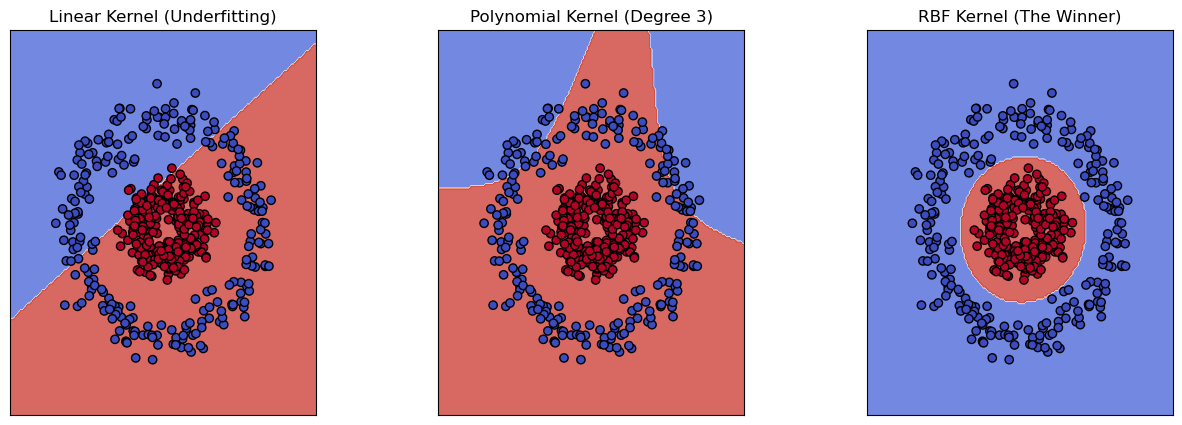

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

# 1. Define the Kernels to compare
# We use degree=3 for Polynomial to give it some 'curve'
kernels = ['linear', 'poly', 'rbf']
models = [svm.SVC(kernel=k, degree=3, gamma='auto') for k in kernels]
models = [clf.fit(X, y) for clf in models]

# 2. Create a mesh grid to plot the decision boundaries
h = .02  # step size in the mesh
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 3. Plot the results side-by-side
fig, sub = plt.subplots(1, 3, figsize=(15, 5))
plt.subplots_adjust(wspace=0.4, hspace=0.4)

titles = ['Linear Kernel (Underfitting)', 
          'Polynomial Kernel (Degree 3)', 
          'RBF Kernel (The Winner)']

for clf, title, ax in zip(models, titles, sub.flatten()):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.8)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    ax.set_title(title)
    ax.set_xticks(())
    ax.set_yticks(())

plt.show()

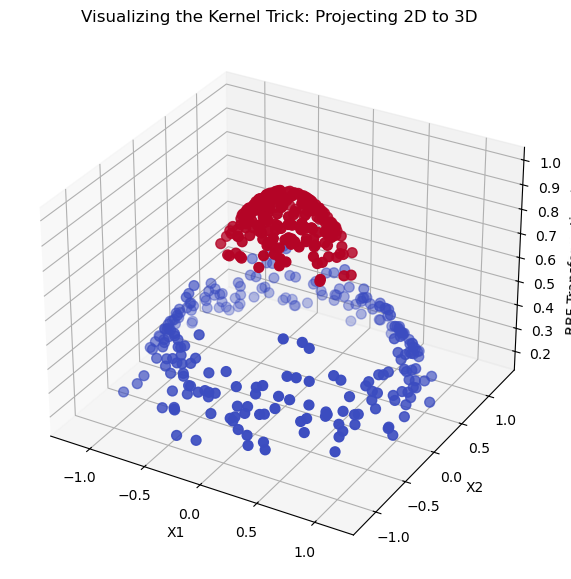

In [9]:
from mpl_toolkits import mplot3d

# Create a 'Z' axis based on the RBF distance from the center
r = np.exp(-(X ** 2).sum(1))

fig = plt.figure(figsize=(10, 7))
ax = plt.subplot(projection='3d')
ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='coolwarm')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('RBF Transformation (Z)')
ax.set_title('Visualizing the Kernel Trick: Projecting 2D to 3D')
plt.show()